In [90]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from statsmodels.tsa.stattools import ccf

## 3.1 DATA FETCHING
Read the data and plot the three non-lagged time series (Ph,Tdelta,Gv). Describe the time series
and if you can see some dependencies between the variables.

In [38]:
df = pd.read_csv("data/box_data_60min.csv")
df.head()

,thour,tdate,Ph,Tdelta,Gv,Ph.l0,Ph.l1,Ph.l2,Ph.l3,Ph.l4,...,Gv.l1,Gv.l2,Gv.l3,Gv.l4,Gv.l5,Gv.l6,Gv.l7,Gv.l8,Gv.l9,Gv.l10
0,19,2013-01-30 02:00:00,56,13.253583,-0.498643,56,55,57,57,58,...,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700,8.262339,20.475484
1,20,2013-01-30 03:00:00,54,13.181458,-1.127035,54,56,55,57,57,...,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700,8.262339
2,21,2013-01-30 04:00:00,55,12.968792,-0.643298,55,54,56,55,57,...,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700
3,22,2013-01-30 05:00:00,54,12.667750,-0.456008,54,55,54,56,55,...,-0.643298,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776
4,23,2013-01-30 06:00:00,54,12.605250,-1.534060,54,54,55,54,56,...,-0.456008,-0.643298,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267


In [39]:
df.describe()

,thour,Ph,Tdelta,Gv,Ph.l0,Ph.l1,Ph.l2,Ph.l3,Ph.l4,Ph.l5,...,Gv.l1,Gv.l2,Gv.l3,Gv.l4,Gv.l5,Gv.l6,Gv.l7,Gv.l8,Gv.l9,Gv.l10
count,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,...,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000
mean,134.000000,74.709957,20.636638,51.246370,74.783550,74.770563,74.926407,74.900433,74.900433,74.826840,...,50.714305,47.949382,46.870573,45.927411,44.778637,44.501627,44.329465,44.283781,44.318730,44.407650
std,66.828138,18.025292,3.310936,122.629162,17.904964,17.918273,17.602340,17.624428,17.624428,17.655283,...,122.585691,116.318231,115.599021,115.089166,114.217872,114.250300,114.288103,114.303828,114.291521,114.264827
min,19.000000,14.000000,12.573000,-2.226486,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,-2.226486,-2.226486,-2.226486,-2.226486,-2.226486,-2.226486,-2.226486,-2.226486,-2.226486,-2.226486
25%,76.500000,67.000000,18.252792,-0.650363,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,...,-0.650363,-0.650363,-0.650363,-0.650363,-0.672537,-0.678456,-0.678456,-0.678456,-0.678456,-0.678456
50%,134.000000,76.000000,21.375875,-0.169945,76.000000,76.000000,76.000000,76.000000,76.000000,75.000000,...,-0.178408,-0.198030,-0.200307,-0.205313,-0.210594,-0.215003,-0.215714,-0.215714,-0.215714,-0.215714
75%,191.500000,88.500000,23.547583,26.806097,88.500000,88.500000,88.500000,88.500000,88.500000,88.500000,...,25.872586,25.029070,23.822901,22.318112,21.175614,20.361604,20.156048,20.156048,20.156048,20.321019
max,249.000000,98.000000,25.444333,876.008527,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,...,876.008527,876.008527,876.008527,876.008527,876.008527,876.008527,876.008527,876.008527,876.008527,876.008527


We can see that there are 231 observations, mean and std are described. We look at the first three columns, which have no missing values: as magnitude differs significantly for each case, we plot them separately.

<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
/var/folders/fb/wkd3ltnj40qb6km7wd9gfdz40000gn/T/ipykernel_11279/906986275.py:10: SyntaxWarning: invalid escape sequence '\c'
  axes[1].set_ylabel('Temp ($^\circ$C)')


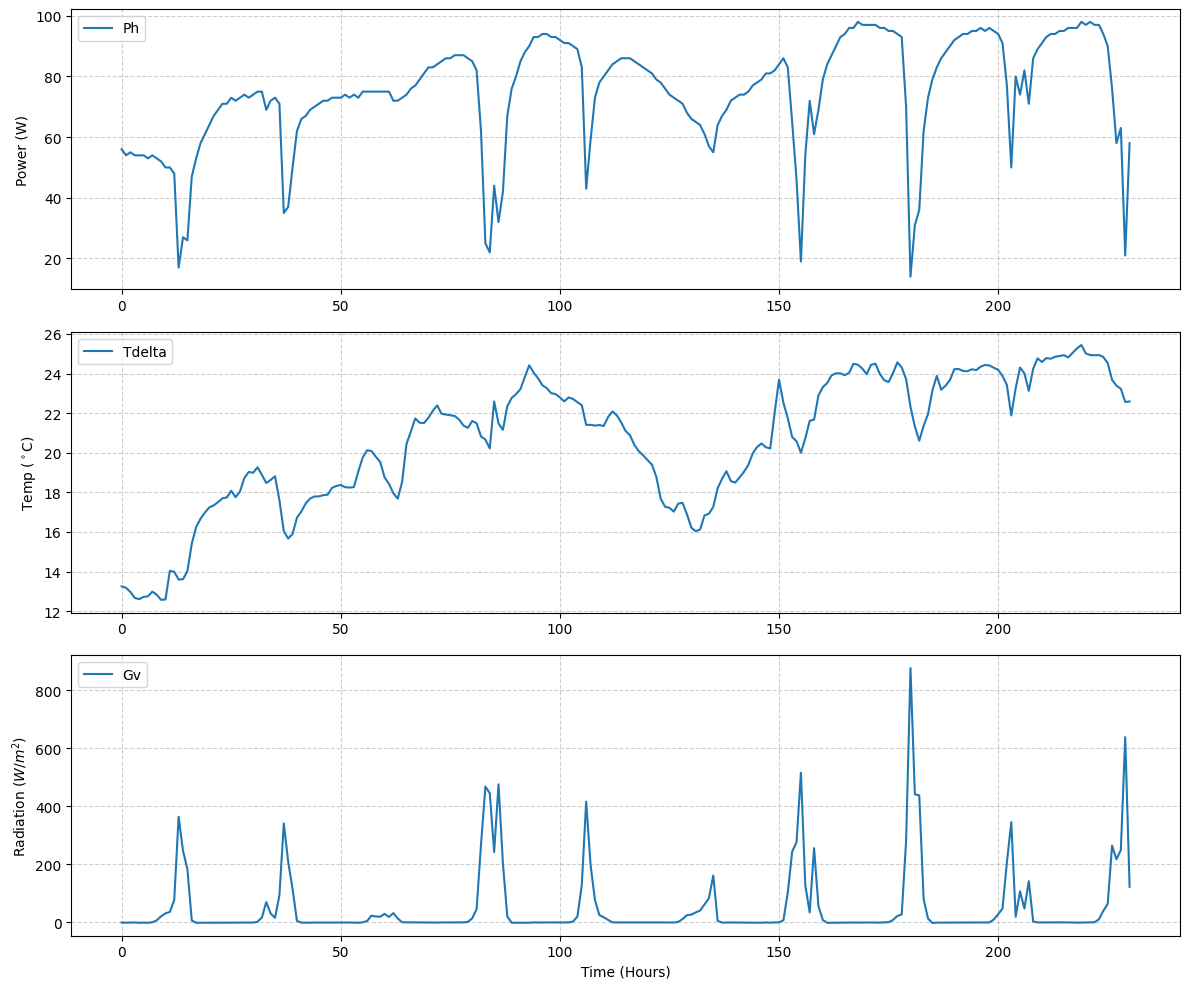

In [40]:
fig, axes = plt.subplots(3, 1, figsize= (12,10))

axes[0].plot(df['Ph'], label = 'Ph')
axes[0].grid(True, linestyle='--', alpha=0.6) 
axes[0].set_ylabel('Power (W)')
axes[0].legend(loc = 'upper left')

axes[1].plot(df['Tdelta'], label = 'Tdelta')
axes[1].grid(True, linestyle='--', alpha=0.6) 
axes[1].set_ylabel('Temp ($^\circ$C)')
axes[1].legend()

axes[2].plot(df['Gv'], label = 'Gv')
axes[2].grid(True, linestyle='--', alpha=0.6) 
axes[2].set_ylabel('Radiation ($W/m^2$)')
axes[2].set_xlabel('Time (Hours)')
axes[2].legend(loc = 'upper left')

plt.tight_layout()
plt.show()

The last plot is the most interpretable, as it represents solar radiations, it shows peaks during daylight and it has seasonality of 24 hours.
Correspondingly to these spikes, the heating Power dips down.
This reflects the thermostatic control compensating for solar heat gains.
Additionally, Tdelta shows a positive relationship with Ph, because a higher temperature gradient represents a larger heating load that the electrical heaters must compensate for.

## 3.2 SPLIT DATA
Split the data into a train and test set, such that ”2013-02-06 00:00” is the last data point in the
training set (i.e. thour = 1,...,167 is the training set). From now on, work only on the training
set, except where explicitly told to use the test set

In [49]:
df_train = df[df['thour'] < 168]
df_test = df[df['thour'] > 167]

## 3.3 DATA INVESTIGATION
Investigate the variables and their relations: e.g. with scatter, auto-correlation and cross-correlation
plots. Most focus on Ph. Highlight key aspects of the dynamics and interrelationships among
the variables. What can be seen directly and what cannot?

Since our aim is to predict the correct Ph, the following investigations will have Ph as the dependent variable

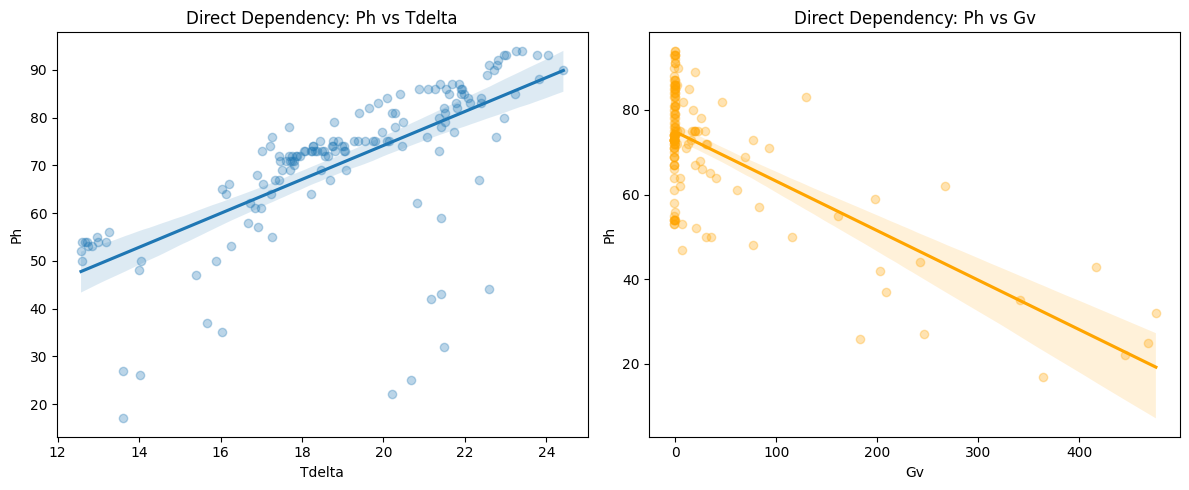

In [ ]:
# scatter
# we use regplot from seaborn bcs it automatically calculates regression lines
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=df_train, x='Tdelta', y='Ph', ax=ax[0], scatter_kws={'alpha':0.3})
ax[0].set_title('Ph vs Tdelta')
sns.regplot(data=df_train, x='Gv', y='Ph', ax=ax[1], scatter_kws={'alpha':0.3}, color='orange')
ax[1].set_title('Ph vs Gv')
plt.tight_layout()
plt.show()

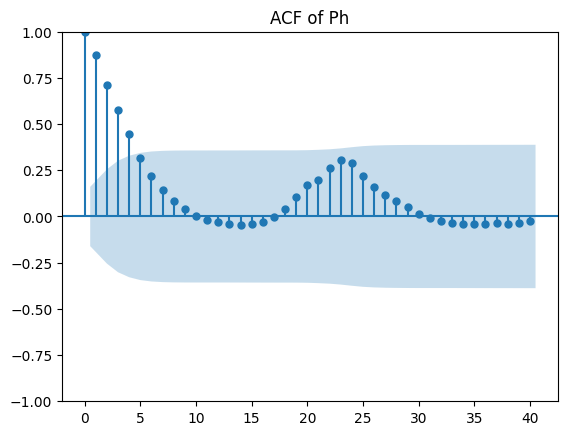

In [ ]:
# auto-correlation rho
plot_acf(df_train['Ph'], lags = 40)
plt.title('ACF of Ph')
plt.show()

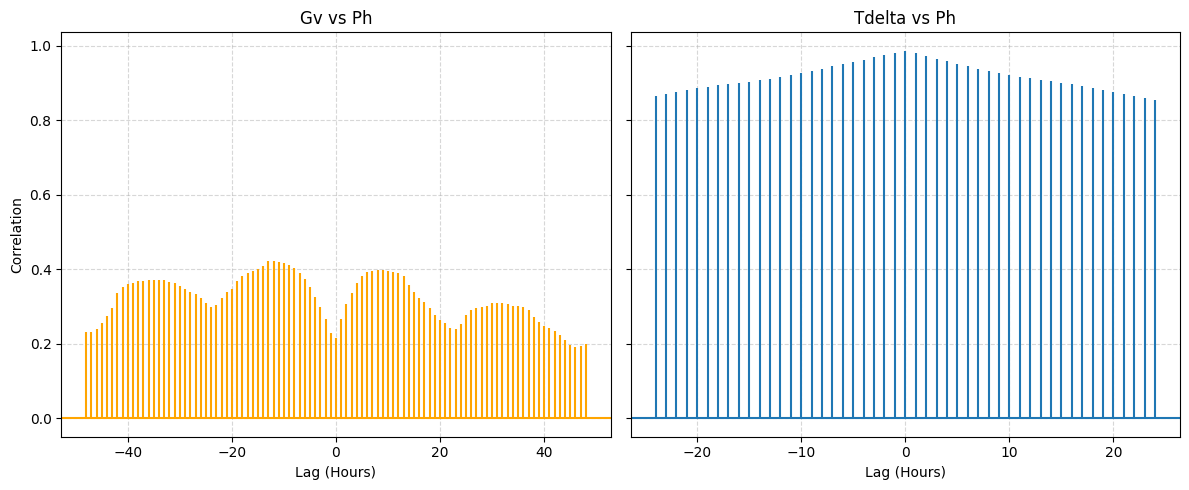

In [81]:
#cross-correlation
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# CCF: Solar (Gv) vs Heating (Ph)
# we put 48h lags to see periodicity
ax[0].xcorr(df_train['Gv'], df_train['Ph'], maxlags=48, color='orange')
ax[0].set_title('Gv vs Ph')
ax[0].set_xlabel('Lag (Hours)')
ax[0].grid(True, linestyle='--', alpha=0.5)

# CCF: Temperature (Tdelta) vs Heating (Ph)
ax[1].xcorr(df_train['Tdelta'], df_train['Ph'], maxlags=24)
ax[1].set_title('Tdelta vs Ph')
ax[1].set_xlabel('Lag (Hours)')
ax[1].grid(True, linestyle='--', alpha=0.5)

ax[0].set_ylabel('Correlation')
plt.tight_layout()
plt.show()

ACF shows damped exponentials, so we exclude the process to be a purely MA(q) model. Instead, this behaviour suggests an AR component.

Looking at cross correlation:
1. Tdelta vs Ph shows an extremely high positive correlation (near 1.0) centered at Lag 0, so that the temperature difference is the primary driver of heating power. Also, the bars stay very high for all 15 lags, which means that the two variables remain correlated also for significant lags in time. In other terms, we can say that Tdelta is highly autocorrelated.
2. Gv vs Ph shows that the relationship between solar radiation andd heating is a repeating cycle of 24 hours. At Lag 0 we find a local minimum of approximately 0.2. While we expect a physical negative dependency (solar gain reducing heating), the raw CCF remains positive. We can interpret this as an uncorrelation between the tempreature being high, and the sun shining (it can happen the other way around) and a strong dominance of the temperature gradient (T delta).

## 3.4 IMPULSE RESPONSE
Estimate the impulse response from Tdelta and Gv to Ph make it up to lag 10. Present it for both variables in plots and comment.

First of all, the impulse response function exists for every linear and time invariant system (Theorem 4.1).
In our case, we have found a linear relation from the scatter plots between Ph and GV, and Ph and Tdelta, so we can assume the system to be linear. Also we can assume it is time-invariant in the sense of the Def 4.2 because the physical properties of the box and the operational behaviour of the thermostat are constant over the period of the experiment: so a specific weather pattern will result in the same heating response at any time it occurs during the study.

We therefore search the impulse response in the form of Theorem 4.1. We approximate, which means that we do not consider the effect of noise.
$$P_{h,t} \approx \sum_{k=0}^{10} h_{k}^{(T)} T_{delta,t-k} + \sum_{k=0}^{10} h_{k}^{(G)} G_{v,t-k}$$

LS estimates - unweighted, so it should be used only if the variance of the residuals is constant and residuals are mutually independent
WLS - we do not know the variance
ML estimates - based on the assumption of normality in the noise. We use this one

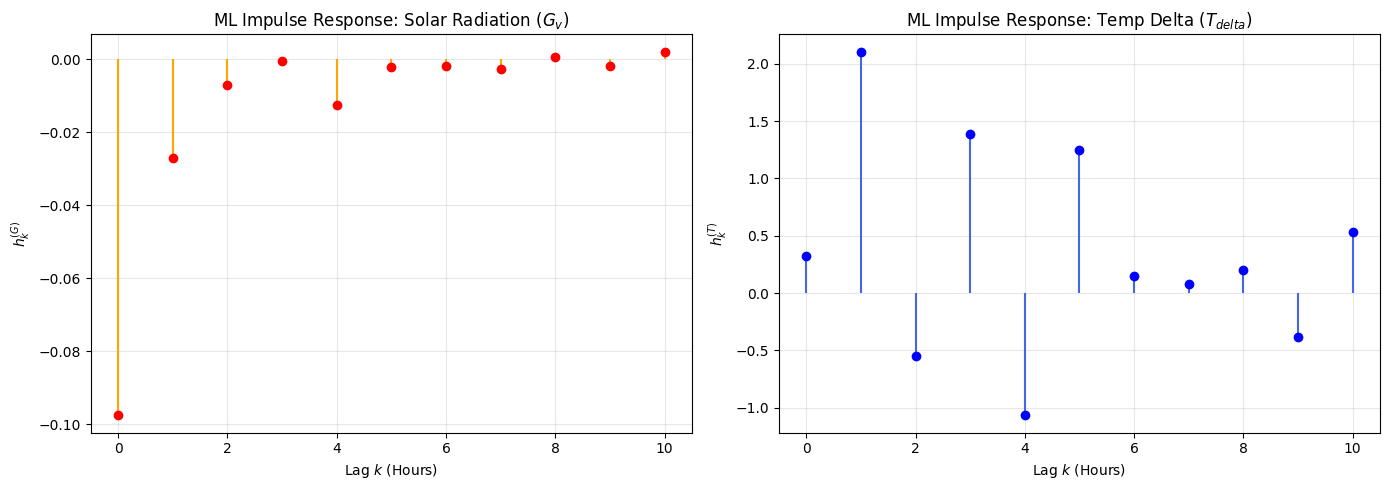

                               SARIMAX Results                                
Dep. Variable:                     Ph   No. Observations:                  149
Model:                        SARIMAX   Log Likelihood                -308.183
Date:                Fri, 03 Apr 2026   AIC                            662.366
Time:                        19:44:04   BIC                            731.457
Sample:                             0   HQIC                           690.436
                                - 149                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Gv.l0         -0.0973      0.002    -41.811      0.000      -0.102      -0.093
Gv.l1         -0.0270      0.003     -9.247      0.000      -0.033      -0.021
Gv.l2         -0.0072      0.004     -1.737      0.0

In [ ]:
# columns for the lags (0 to 10)
gv_cols = [f'Gv.l{i}' for i in range(11)]
tdelta_cols = [f'Tdelta.l{i}' for i in range(11)]
X_cols = gv_cols + tdelta_cols

X = df_train[X_cols]
y = df_train['Ph']

# We fit the model using Maximum Likelihood
# We use order=(0,0,0) bcs we already input the correct variables X
# no seasonality, lag 10 < 24h
model_ml = sm.tsa.statespace.SARIMAX(y, exog=X, order=(0, 0, 0))
results = model_ml.fit()

# results.params contains the estimated weights for each lag
h_G = [results.params[col] for col in gv_cols]
h_T = [results.params[col] for col in tdelta_cols]



# Plotting the Impulse Response
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Solar Radiation Response
ax[0].stem(range(11), h_G, basefmt=" ", linefmt='orange', markerfmt='or')
ax[0].set_title('ML Impulse Response: Solar Radiation ($G_v$)')
ax[0].set_xlabel('Lag $k$ (Hours)')
ax[0].set_ylabel('$h_k^{(G)}$')
ax[0].grid(True, alpha=0.3)

# Temperature Difference Response
ax[1].stem(range(11), h_T, basefmt=" ", linefmt='royalblue', markerfmt='ob')
ax[1].set_title('ML Impulse Response: Temp Delta ($T_{delta}$)')
ax[1].set_xlabel('Lag $k$ (Hours)')
ax[1].set_ylabel('$h_k^{(T)}$')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the summary to check Log-Likelihood and AIC
print(results.summary())

Solar Radiation ($G_v$) 
As physically expected, the estimated impulse response weights ($h_k^{(G)}$) are predominantly **negative**, confirming that solar gain reduces the required heating power. 
* **Significance**: Only the first two lags ($k=0, 1$) are statistically significant ($p < 0.05$). This indicates that the primary cooling effect of solar radiation is immediate. 
* **Noise at High Lags**: The minor positive values at lags 8 and 9 are statistically insignificant ($p > 0.05$) and can be attributed to stochastic noise or diurnal confounding effects that occur far from the initial impulse.

Temperature Difference ($T_{delta}$)
The response for the temperature gradient oscillates but remains largely positive, as increased heat loss to the environment requires higher power input. 
* **Physical Delay**: Notably, the response at **Lag 1** is significantly stronger and more certain ($p < 0.001$) than at Lag 0. This characterizes the **thermal inertia** and insulation properties of the test box, representing the time required for external temperature changes to conduct through the envelope and affect the internal thermostat.



Residual Diagnostics (Ljung-Box)
The Ljung-Box test yields a high statistic ($Q = 24.02$) with a p-value of $0.00$. This results in a formal **rejection of the white noise hypothesis** for the residuals. 
* **Implication**: Such a significant result indicates that the current FIR (Finite Impulse Response) model fails to capture the internal dynamics of the system. The remaining pattern in the residuals suggests **serial correlation**, likely due to the "memory" of the internal air temperature. 
* **Conclusion**: This diagnostic failure justifies the transition to a parametric **ARX model** in the following section to properly account for these autoregressive dependencies.

I wouldnt trust the forecast

## 3.5 LINEAR REGRESSION MODEL
Fit the linear regression model
$$
P_{h,t} = ω_1 T_{delta,t} + ω_2 G_{v,t} + ε_t
$$
The error is assumed εt ∼N(0,σ2) and i.i.d.
Analyse the estimation result, one-step prediction, residuals with plots, ACF and CCF. Comment
with focus on the potential need for a model which includes a transfer function.

In [ ]:
# 1. Generate a "Control" variable (Pure White Noise)
# This acts as a baseline to see what 'Ph' does with a 0-correlation input
np.random.seed(42) # For reproducibility
df_train['white_noise'] = np.random.normal(0, 1, size=len(df_train))

X_cols = ['Tdelta', 'Gv', 'white_noise']
X = df_train[X_cols]
y = df_train['Ph']

# Add a constant: this sets a baseline for Pv so it doesn't 
# necessarily need to be == 0 when Tdelta = Gv = 0
X = sm.add_constant(X)

# 4. Fit the ML model
model_ml = sm.tsa.statespace.SARIMAX(y, exog=X, order=(0, 0, 0))
results = model_ml.fit(disp=False)

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                     Ph   No. Observations:                  149
Model:                        SARIMAX   Log Likelihood                -447.042
Date:                Fri, 03 Apr 2026   AIC                            904.084
Time:                        21:05:18   BIC                            919.104
Sample:                             0   HQIC                           910.186
                                - 149                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           9.8324      2.984      3.295      0.001       3.984      15.681
Tdelta          3.4185      0.152     22.520      0.000       3.121       3.716
Gv             -0.1130      0.003    -33.109    

Both weather variables have p<0.001, while white_noise has p=0.780. This proves the model is correctly identifying physical signal over random noise.
But we notice that the Ljung-Box statistic has a value even higher than in the previous case. This suggests that by ignoring the "history" of the inputs (the transfer function), the model's accuracy has dropped significantly.

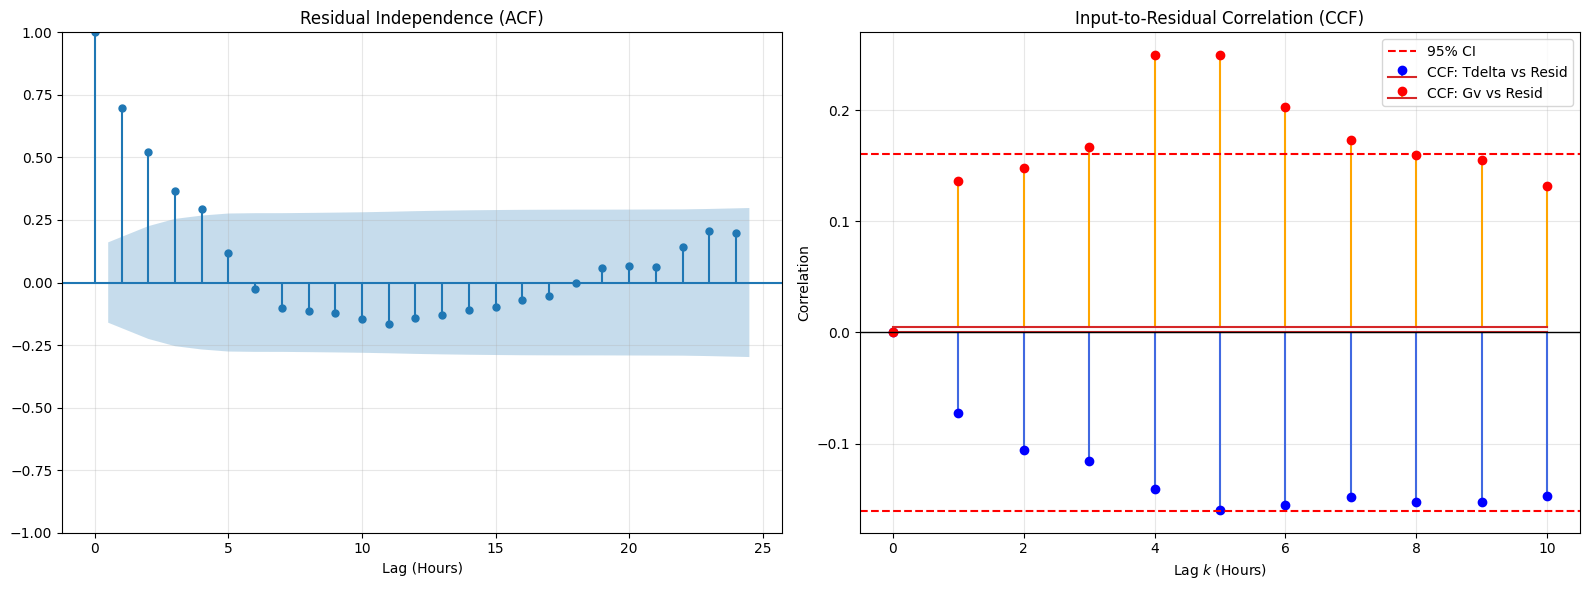

In [ ]:
# Extract residuals
residuals = results.resid
n_obs = len(df_train)
conf_level = 1.96 / np.sqrt(n_obs) #from the theory, 95% confidence in gaussian distribution

# ccf(x, y) correlates x_past with y_now
ccf_tdelta = ccf(df_train['Tdelta'], residuals, adjusted=False)[:11]
ccf_gv = ccf(df_train['Gv'], residuals, adjusted=False)[:11]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  ACF
plot_acf(residuals, lags=24, ax=axes[0], title='Residual Independence (ACF)')
axes[0].set_xlabel('Lag (Hours)')
axes[0].grid(True, alpha=0.3)

#  CCF
axes[1].stem(range(11), ccf_tdelta, linefmt='royalblue', 
             markerfmt='ob', label='CCF: Tdelta vs Resid')
axes[1].stem(range(11), ccf_gv, linefmt='orange', 
             markerfmt='or', label='CCF: Gv vs Resid', bottom=0.005) # slight offset for visibility

# Add the 95% Confidence Interval
axes[1].axhline(y=conf_level, color='red', linestyle='--', label='95% CI')
axes[1].axhline(y=-conf_level, color='red', linestyle='--')
axes[1].axhline(y=0, color='black', linewidth=1)

axes[1].set_title('Input-to-Residual Correlation (CCF)')
axes[1].set_xlabel('Lag $k$ (Hours)')
axes[1].set_ylabel('Correlation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The Residual Independence (ACF) plot exhibit a clear damped exponential decay, which is a diagnostic signature of an autoregressive process. This confirms that the current residuals are not white noise and that the system possesses internal state memory that the static model ignores.

The Input-to-Residual Correlation (CCF) further clarifies this deficiency. We observe statistically significant correlations ($> \pm 1.96/\sqrt{N}$) for both $G_v$ and $T_{delta}$ peaking at Lags 4 and 5. 
* The positive correlation with $G_v$ suggests that solar gains from 5 hours ago are still influencing the current heating demand. 
* The negative correlation with $T_{delta}$ indicates a delayed thermal response to temperature gradients.

Because these dependencies exist far beyond Lag 0, the static linear model is physically insufficient. These results provide a definitive mandate for a **Transfer Function (ARX) model** capable of mapping the delayed, rational dynamics of the test box's envelope.

## 3.6 FIRST ORDER ARX
$$
P_{h,t} = - \phi_1P_{h,t-1}+ ω_1 T_{delta,t} + ω_2 G_{v,t} + ε_t
$$
Analyse the one-step predictions and residuals as above. Comment, was an improvement achieved?

                               SARIMAX Results                                
Dep. Variable:                     Ph   No. Observations:                  149
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -386.314
Date:                Fri, 03 Apr 2026   AIC                            782.629
Time:                        23:29:22   BIC                            797.648
Sample:                             0   HQIC                           788.731
                                - 149                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Tdelta          3.8635      0.105     36.643      0.000       3.657       4.070
Gv             -0.0878      0.002    -51.176      0.000      -0.091      -0.084
white_noise     0.2536      0.234      1.082    

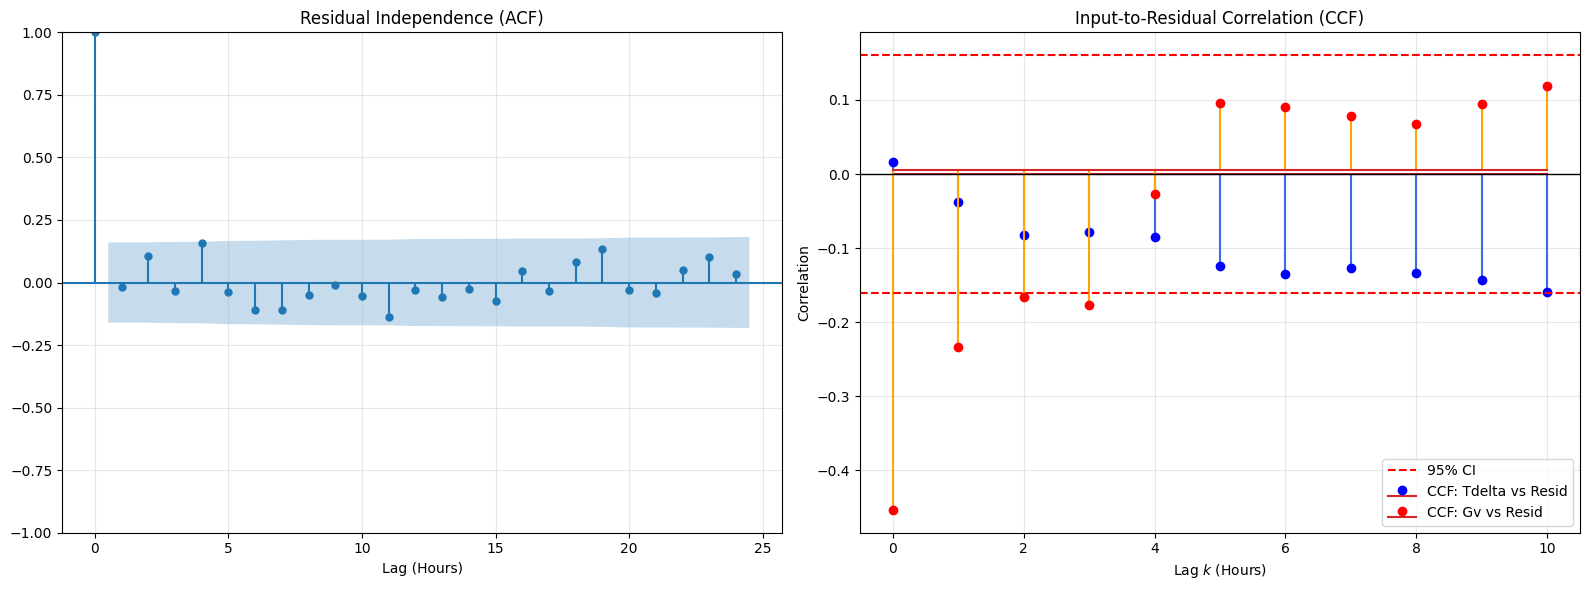

In [97]:
# same code as before, just changing order of SARIMAX
# 1. Generate a "Control" variable (Pure White Noise)
# This acts as a baseline to see what 'Ph' does with a 0-correlation input
np.random.seed(42) # For reproducibility
df_train['white_noise'] = np.random.normal(0, 1, size=len(df_train))

X_cols = ['Tdelta', 'Gv', 'white_noise']
X = df_train[X_cols]
y = df_train['Ph']

# 4. Fit the ML model
model_ml = sm.tsa.statespace.SARIMAX(y, exog=X, order=(1, 0, 0))
results = model_ml.fit(disp=False)

print(results.summary())
# Extract residuals
residuals = results.resid
n_obs = len(df_train)
conf_level = 1.96 / np.sqrt(n_obs) #from the theory, 95% confidence in gaussian distribution

# ccf(x, y) correlates x_past with y_now
ccf_tdelta = ccf(df_train['Tdelta'], residuals, adjusted=False)[:11]
ccf_gv = ccf(df_train['Gv'], residuals, adjusted=False)[:11]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  ACF
plot_acf(residuals, lags=24, ax=axes[0], title='Residual Independence (ACF)')
axes[0].set_xlabel('Lag (Hours)')
axes[0].grid(True, alpha=0.3)

#  CCF
axes[1].stem(range(11), ccf_tdelta, linefmt='royalblue', 
             markerfmt='ob', label='CCF: Tdelta vs Resid')
axes[1].stem(range(11), ccf_gv, linefmt='orange', 
             markerfmt='or', label='CCF: Gv vs Resid', bottom=0.005) # slight offset for visibility

# Add the 95% Confidence Interval
axes[1].axhline(y=conf_level, color='red', linestyle='--', label='95% CI')
axes[1].axhline(y=-conf_level, color='red', linestyle='--')
axes[1].axhline(y=0, color='black', linewidth=1)

axes[1].set_title('Input-to-Residual Correlation (CCF)')
axes[1].set_xlabel('Lag $k$ (Hours)')
axes[1].set_ylabel('Correlation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We see a huge improvement, especially Jiung Box is now equal 0.01.
ACF correctly shows ar(1) model, as expected.
Furthermore, the CCF indicates that the AR term has partially captured the delayed response of Tdelta and Gv, reducing the 'echo' effect in the residuals.

## 3.6 SECOND ORDER ARX
$$
P_{h,t} = -\phi_1 P_{h,t-1} - \phi_2 P_{h,t-2} + \omega_{1,0} T_{\text{delta},t} + \omega_{1,1} T_{\text{delta},t-1} + \omega_{2,0} G_{v,t} + \omega_{2,1} G_{v,t-1} + \epsilon_t
$$
Plot BIC and AIC vs. the increasing model order. Explain the difference between the two curves,
and consider what model order you would select based on this?

                               SARIMAX Results                                
Dep. Variable:                     Ph   No. Observations:                  149
Model:               SARIMAX(2, 0, 2)   Log Likelihood                -385.597
Date:                Fri, 03 Apr 2026   AIC                            785.194
Time:                        23:33:46   BIC                            806.221
Sample:                             0   HQIC                           793.737
                                - 149                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Tdelta         3.8667      0.103     37.713      0.000       3.666       4.068
Gv            -0.0877      0.002    -43.471      0.000      -0.092      -0.084
ar.L1          0.0721      0.397      0.182      0.8

/Users/valentinatrolese/Desktop/DTU_courses/time_series/time_series_analysis-1/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/valentinatrolese/Desktop/DTU_courses/time_series/time_series_analysis-1/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/valentinatrolese/Desktop/DTU_courses/time_series/time_series_analysis-1/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


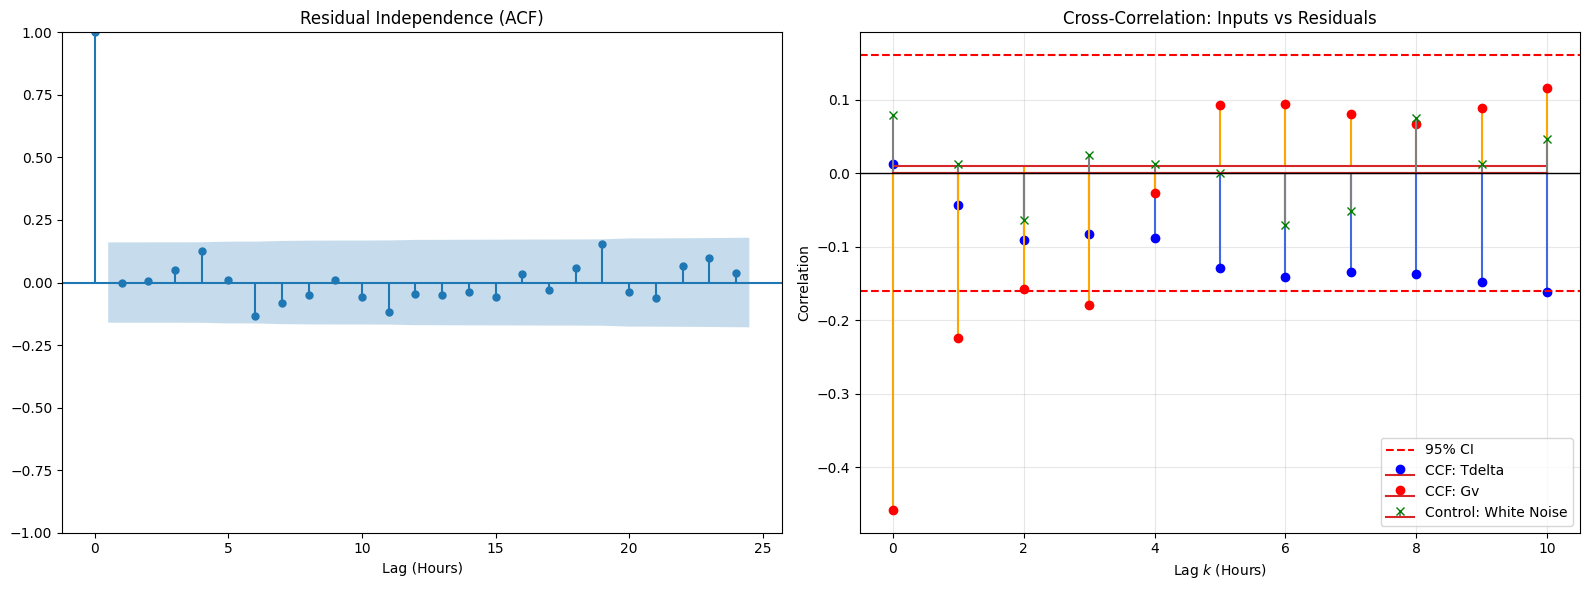

In [99]:
# same code as before, just changing order of SARIMAX
# 1. Generate a "Control" variable (Pure White Noise)
# This acts as a baseline to see what 'Ph' does with a 0-correlation input
np.random.seed(42) # For reproducibility
df_train['white_noise'] = np.random.normal(0, 1, size=len(df_train))

X_cols = ['Tdelta', 'Gv']
X = df_train[X_cols]
y = df_train['Ph']

# 4. Fit the ML model
model_ml = sm.tsa.statespace.SARIMAX(y, exog=X, order=(2, 0, 2))
results = model_ml.fit(disp=False)

print(results.summary())
# Extract residuals
residuals = results.resid
n_obs = len(df_train)
conf_level = 1.96 / np.sqrt(n_obs) #from the theory, 95% confidence in gaussian distribution

# ccf(x, y) correlates x_past up to 11 lags with y_now
ccf_tdelta = ccf(df_train['Tdelta'], residuals, adjusted=False)[:11]
ccf_gv = ccf(df_train['Gv'], residuals, adjusted=False)[:11]
ccf_wn = ccf(df_train['white_noise'], residuals, adjusted=False)[:11]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  ACF
plot_acf(residuals, lags=24, ax=axes[0], title='Residual Independence (ACF)')
axes[0].set_xlabel('Lag (Hours)')

#  CCF
axes[1].stem(range(11), ccf_tdelta, linefmt='royalblue', markerfmt='ob', label='CCF: Tdelta')
axes[1].stem(range(11), ccf_gv, linefmt='orange', markerfmt='or', label='CCF: Gv', bottom=0.01)
axes[1].stem(range(11), ccf_wn, linefmt='gray', markerfmt='xg', label='Control: White Noise')
# Add the 95% Confidence Interval
axes[1].axhline(y=conf_level, color='red', linestyle='--', label='95% CI')
axes[1].axhline(y=-conf_level, color='red', linestyle='--')
axes[1].axhline(y=0, color='black', linewidth=1)

axes[1].set_title('Cross-Correlation: Inputs vs Residuals')
axes[1].set_xlabel('Lag $k$ (Hours)')
axes[1].set_ylabel('Correlation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The SARIMAX(2,0,2) model successfully achieves the primary goal of model identification: the residuals are white noise (Prob(Q)=0.99) and the cross-correlations with exogenous inputs are neutralized. Visually, the model is 'correct.'

However, from a parametric standpoint, the model is over-determined. The high p-values for all AR and MA terms, combined with the lack of numerical convergence, indicate redundancy in the model structure. Physically, this implies that a simpler, lower-order transfer function (such as an ARX(1) or ARMA(1,1) noise structure) would provide a more parsimonious and stable description of the test box without sacrificing the whiteness of the residuals.

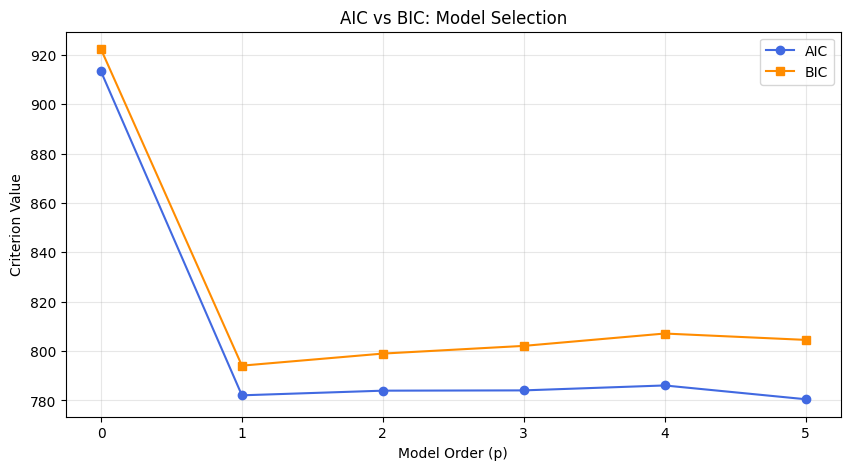

In [100]:
aic_values = []
bic_values = []
orders = range(0, 6) # Static model (0) to AR(5)

for p in orders:
    # Fitting SARIMAX(p, 0, 0) with Tdelta and Gv as exog
    model = sm.tsa.statespace.SARIMAX(y, exog=X, order=(p, 0, 0))
    res = model.fit(disp=False)
    aic_values.append(res.aic)
    bic_values.append(res.bic)

# Plotting the "Elbow" curves
plt.figure(figsize=(10, 5))
plt.plot(orders, aic_values, label='AIC', marker='o', color='royalblue')
plt.plot(orders, bic_values, label='BIC', marker='s', color='darkorange')
plt.xlabel('Model Order (p)')
plt.ylabel('Criterion Value')
plt.title('AIC vs BIC: Model Selection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 